# Banknote Logistic Regression

Bài này cũng là logistic regression. Mỗi hàng là một tờ tiền. Nhãn class bằng 

Bốn cột số được đo từ ảnh tờ tiền:

- variance
- skewness
- curtosis
- entropy

Bốn số này không phải mệnh giá. Chúng mô tả hình ảnh trên tờ tiền. Mô hình dùng cả bốn cột để ra xác suất tờ đó là giả.


## 1. Đọc dữ liệu


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/banknote.csv")
df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 2. Xem nhãn

762 tờ có class = 0, tức tờ thật. 610 tờ có class = 1, tức tờ giả. Không có ô trống.


In [4]:
# df["class"].?
df["class"].value_counts()


class
0    762
1    610
Name: count, dtype: int64

In [5]:
# df.describe()
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


## 3. Hai nhóm trên biểu đồ

Trục ngang là variance. Trục dọc là skewness. Màu là class.

Hai nhóm tách khá rõ. Tờ giả và tờ thật không nằm trộn dày như bài tiểu đường. Vì vậy accuracy của bài này sẽ cao hơn.


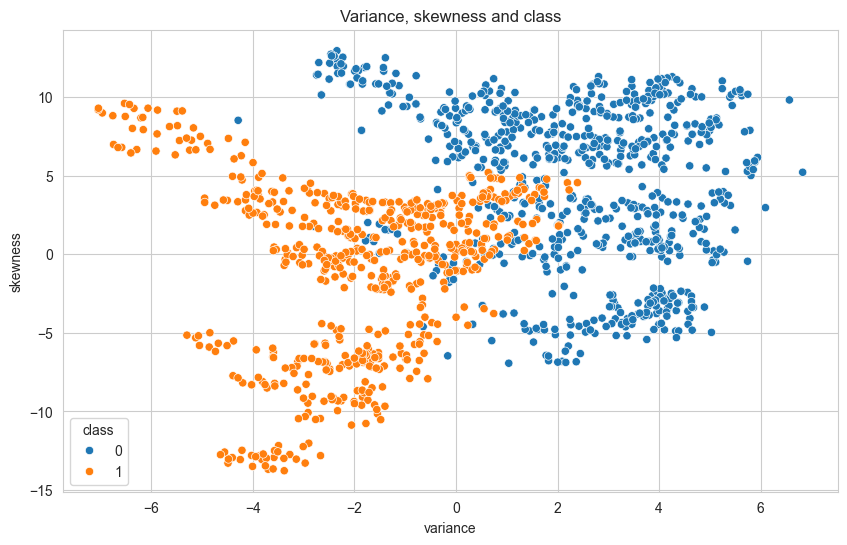

In [2]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="variance", y="skewness", hue="class")
plt.title("Variance, skewness and class")
plt.show()


## 4. Tách feature, label, rồi chia tập học và tập kiểm tra

X là bốn cột số. y là class. 80% hàng để học, 20% hàng để kiểm tra. random_state = 42 giữ cách chia không đổi.


In [6]:
X = df[["variance", "skewness", "curtosis", "entropy"]]
y = df["class"]
print(X.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(1372, 4)


## 5. Huấn luyện

$$z = b + w_1 \times variance + w_2 \times skewness + w_3 \times curtosis + w_4 \times entropy$$

$$P = \frac{1}{1 + e^{-z}}$$

P là xác suất class = 1, tức xác suất tờ giả. intercept_ là bias. coef_ là bốn weight.


In [7]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("rounds =", model.n_iter_[0])
print("bias =", model.intercept_[0])
print("weight =", model.coef_[0])


rounds = 17
bias = 3.5096847339956025
weight = [-3.25806008 -1.78962145 -2.18296135 -0.03927448]


## 6. Thử một tờ giả trong tập kiểm tra

Lấy tờ giả đầu tiên trong tập kiểm tra. predict_proba cho phần tử [0][1], là xác suất tờ giả.

Ngưỡng vẫn là 0.5. Xác suất lớn hơn hoặc bằng 0.5 thì gọi là Forged. Nhỏ hơn thì gọi là Genuine.

score là accuracy trên tập kiểm tra.


In [8]:
fake_index = y_test[y_test == 1].index[0]
note = X_test.loc[[fake_index]]
probability = model.predict_proba(note)[0][1]
label = "Forged" if probability >= 0.5 else "Genuine"
real = "Forged" if y_test.loc[fake_index] == 1 else "Genuine"

print(note)
print("Probability of forged =", f"{probability:.4f}")
print("Prediction =", label)
print("Real =", real)
print("Accuracy =", round(model.score(X_test, y_test), 3))


      variance  skewness  curtosis  entropy
1033    1.5077    1.9596   -3.0584 -0.12243
Probability of forged = 0.8547
Prediction = Forged
Real = Forged
Accuracy = 0.985


## 7. Đọc kết quả

Tờ vừa in có xác suất giả khoảng 0.85, nên dự đoán là Forged. Nhãn thật cũng là Forged.

Accuracy khoảng 0.985, tức khoảng 98 đến 99 tờ trong 100 tờ được gọi đúng. Cao hơn bài tiểu đường vì hai nhóm trên biểu đồ đã tách sẵn. Ngưỡng 0.5 vẫn là cách đọc xác suất, giống bài mua hàng và bài tiểu đường.
